In [13]:
# Core imports
import importlib
from Classes import FileManager as fm
from Classes.DataPlotter import DataPlotter
from Classes import Calculations as calc
import Classes.TelemetryPipeline as telemetry_pipeline
import Classes.EfficiencyAnalysis as ea
import Classes.InteractiveTrackMap as interactive_track_map

# Reload helper modules so notebook picks up file edits without kernel restart
importlib.reload(telemetry_pipeline)
importlib.reload(ea)
importlib.reload(interactive_track_map)

from Classes.TelemetryPipeline import TelemetryConfig, prepare_telemetry_with_track
from Classes.InteractiveTrackMap import build_interactive_track_map

# Folder with run data
folder = r"Data"
latest_file = fm.get_latest_file(folder)
print(latest_file)

# Load latest run
plotter = DataPlotter(latest_file)
plotter.load_data()

# Shared track configuration
TELEMETRY_CONFIG = TelemetryConfig(track_len_m=3832.5)
TRACK_LEN = TELEMETRY_CONFIG.track_len_m

Data\d_75.csv


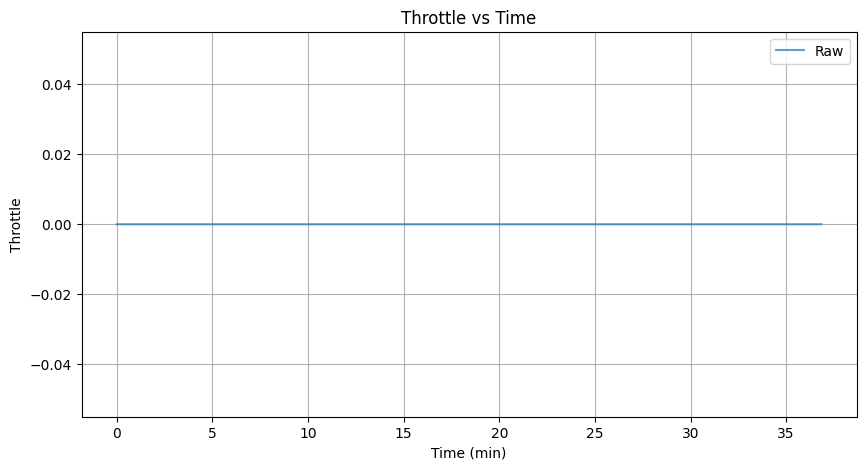

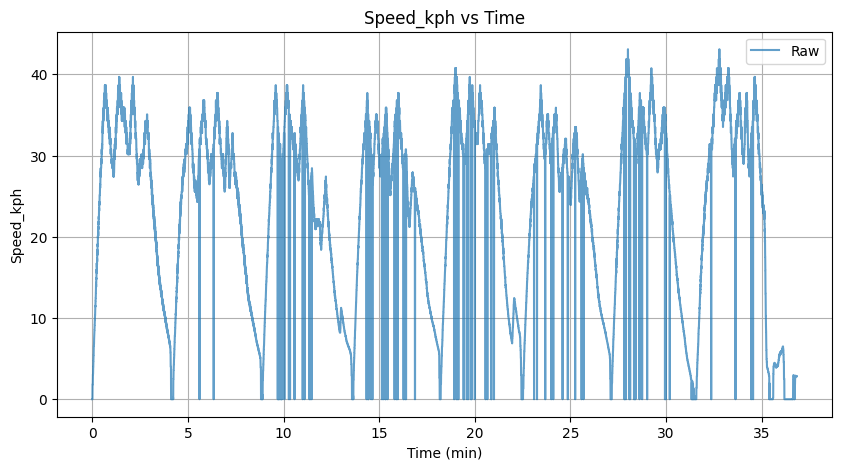

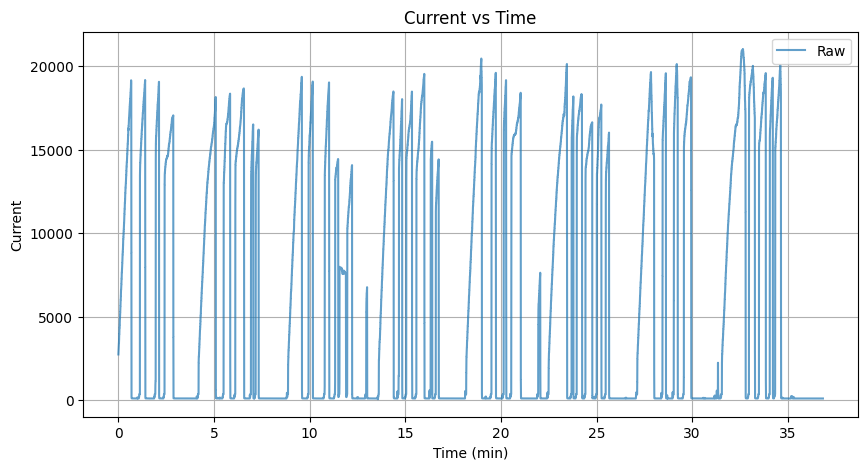

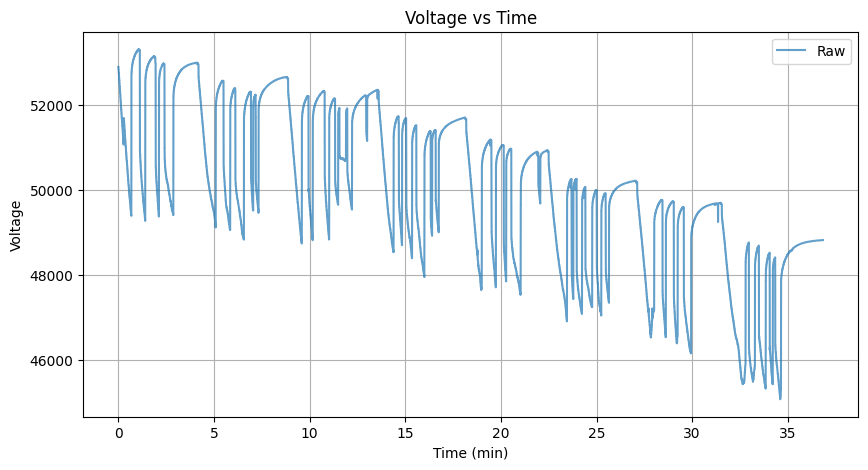

In [14]:
# Plot all columns
plotter.plot_all(smooth_window=0)

In [15]:
calc.get_efficiency(num_laps=2,energy_joules=267_844,track_len_km=TRACK_LEN)

Efficiency: 103022.65 km/kWh


In [16]:
calc.get_total_energy(plotter.data)


Total energy consumed: 644852.1241103064 J or 0.17912559003064066 kWh


# Track Map — IMS Grand Prix Road Course
Mapping **voltage**, **current draw**, and **car speed** onto the track layout.

| Parameter | Value |
|-----------|-------|
| Wheel diameter | 0.55 m |
| Encoder ticks/rev | 4 |
| Distance per tick | π × 0.55 / 4 ≈ 0.432 m |
| Track length | 3.875 km (15.5 / 4) |

In [17]:
from pathlib import Path

track_name = "sem-us-2022-track_coordinates.csv"

search_roots = [
    Path("."),                             # notebook/workspace root
    Path(folder),                           # configured data folder
    Path(latest_file).parent,               # same folder as telemetry file
 ]

candidates = []
for root in search_roots:
    if not root.exists():
        continue
    # exact location check first
    direct = root / track_name
    if direct.exists():
        candidates.append(direct.resolve())
    # recursive search for moved files in subfolders
    candidates.extend(p.resolve() for p in root.rglob(track_name))

# de-duplicate while preserving order
seen = set()
ordered_candidates = []
for p in candidates:
    key = str(p)
    if key not in seen:
        seen.add(key)
        ordered_candidates.append(p)

track_csv_path = ordered_candidates[0] if ordered_candidates else None
if track_csv_path is None:
    raise FileNotFoundError(
        f"Could not find '{track_name}'. Searched under:\n" +
        "\n".join(str(r.resolve()) for r in search_roots if r.exists())
    )

df, track, summary, dist_to_xy = prepare_telemetry_with_track(
    telemetry_df=plotter.data,
    track_csv_path=str(track_csv_path),
    config=TELEMETRY_CONFIG,
 )

print(f"Using track file: {track_csv_path}")
print(f"Wheel dia: {TELEMETRY_CONFIG.wheel_diam_m} m | Circumference: {summary['circumference_m']:.4f} m")
print(
    f"Encoder ticks/rev: {TELEMETRY_CONFIG.encoder_ticks_per_rev} | "
    f"Distance/tick: {summary['dist_per_tick_m']:.4f} m"
 )
print(f"Speed scale: {TELEMETRY_CONFIG.speed_scale}")
if TELEMETRY_CONFIG.chop_seconds > 0:
    print(f"Chopped first {TELEMETRY_CONFIG.chop_seconds}s")
print(f"Total distance: {summary['total_dist_m']:.0f} m ({summary['total_dist_km']:.2f} km)")
print(f"Laps completed: {summary['n_laps']:.2f}")
print(
    f"Max speed: {summary['max_speed_kph']:.1f} kph | "
    f"Avg moving speed: {summary['avg_moving_speed_kph']:.1f} kph"
 )
print(
    f"Voltage: {summary['min_voltage_v']:.1f} - {summary['max_voltage_v']:.1f} V | "
    f"Current: {summary['min_current_a']:.1f} - {summary['max_current_a']:.1f} A"
 )
print(
    f"Start offset: {summary['start_offset_m']:.1f} m (track point #{summary['start_idx']}, "
    f"nearest to {TELEMETRY_CONFIG.start_coords})"
 )
print(f"\nGPS track: {len(track['track_xy'])} pts | arc = {track['total_arc']:.0f} m")

Using track file: C:\Dev\UOSM-CleanTelemProcess\TrackData\sem-us-2022-track_coordinates.csv
Wheel dia: 0.55 m | Circumference: 1.7279 m
Encoder ticks/rev: 4 | Distance/tick: 0.4320 m
Speed scale: 1.06
Total distance: 15230 m (15.23 km)
Laps completed: 3.97
Max speed: 45.7 kph | Avg moving speed: 26.2 kph
Voltage: 45.1 - 53.3 V | Current: 0.1 - 21.0 A
Start offset: 28.9 m (track point #27, nearest to (39.792255, -86.238697))

GPS track: 3833 pts | arc = 3818 m


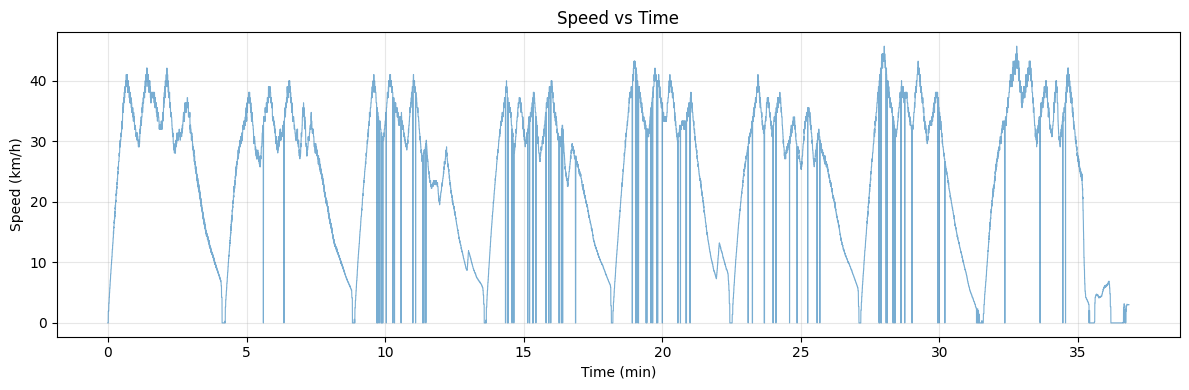

In [18]:
ea.plot_speed_vs_time(df)

# Efficiency Analysis

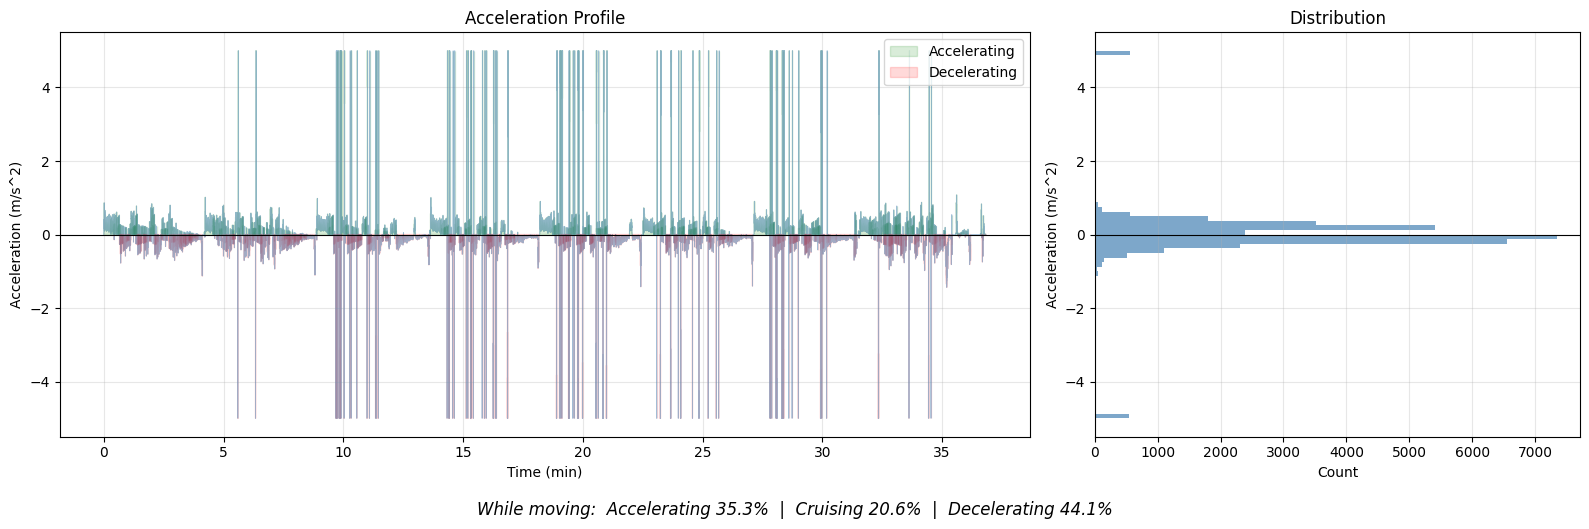

In [19]:
accel = ea.plot_acceleration_profile(df=df, smooth_window=21)

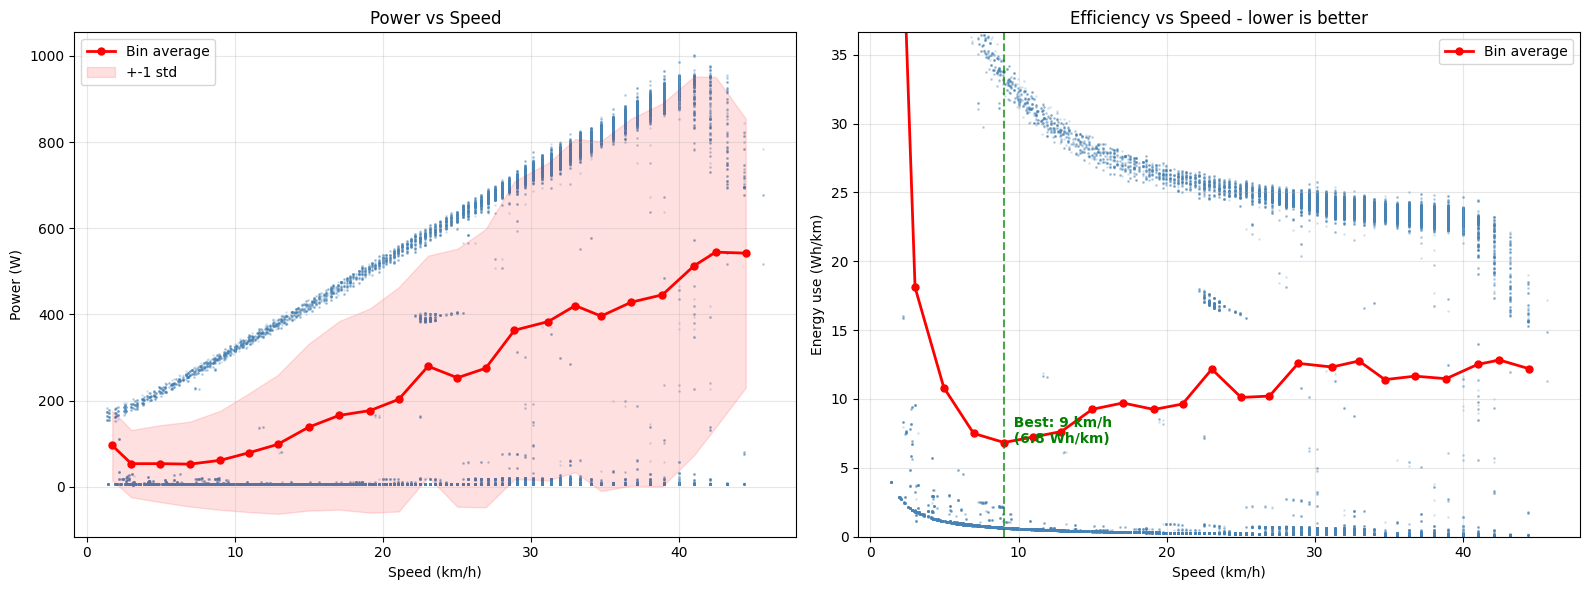

In [20]:
ea.plot_power_vs_speed(df)

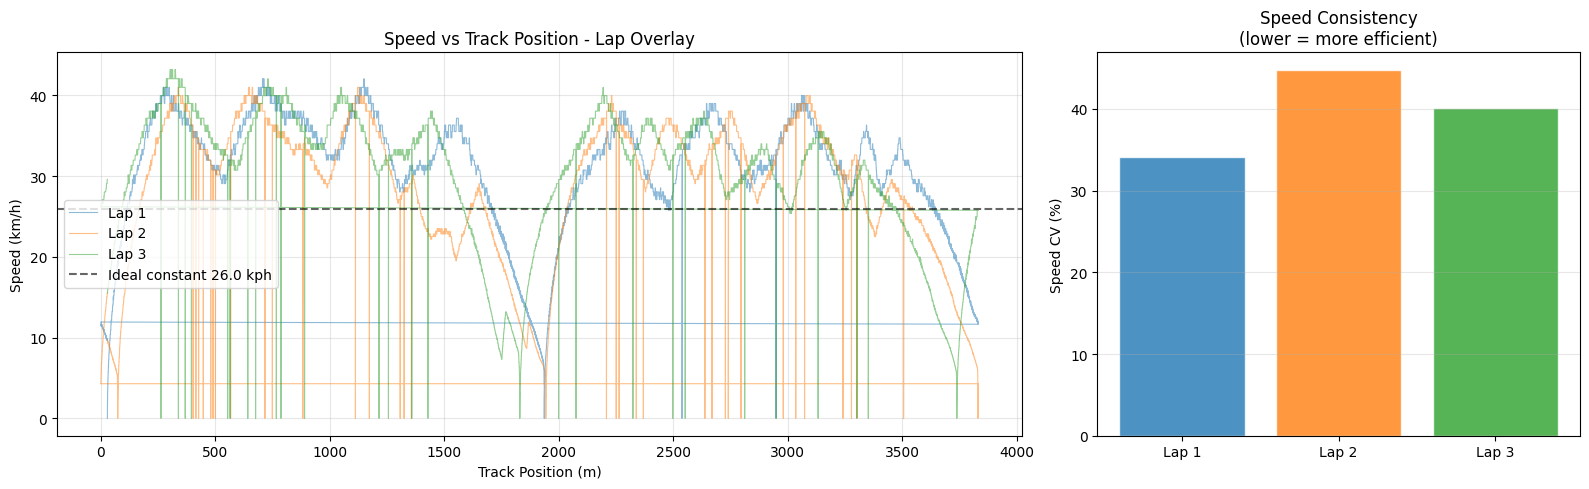

Lap-by-lap speed stats (while moving):
 Lap  Avg (kph)  Std (kph)  CV (%)  Min (kph)  Max (kph)
   1       27.7        9.5    34.2        1.9       42.1
   2       24.1       10.8    44.7        2.0       41.0
   3       26.1       10.5    40.2        1.4       43.2

A lower CV% means steadier speed -> less energy wasted on drag variation.


In [21]:
lap_stats = ea.plot_speed_variance_per_lap(df=df, track_len_m=TRACK_LEN)

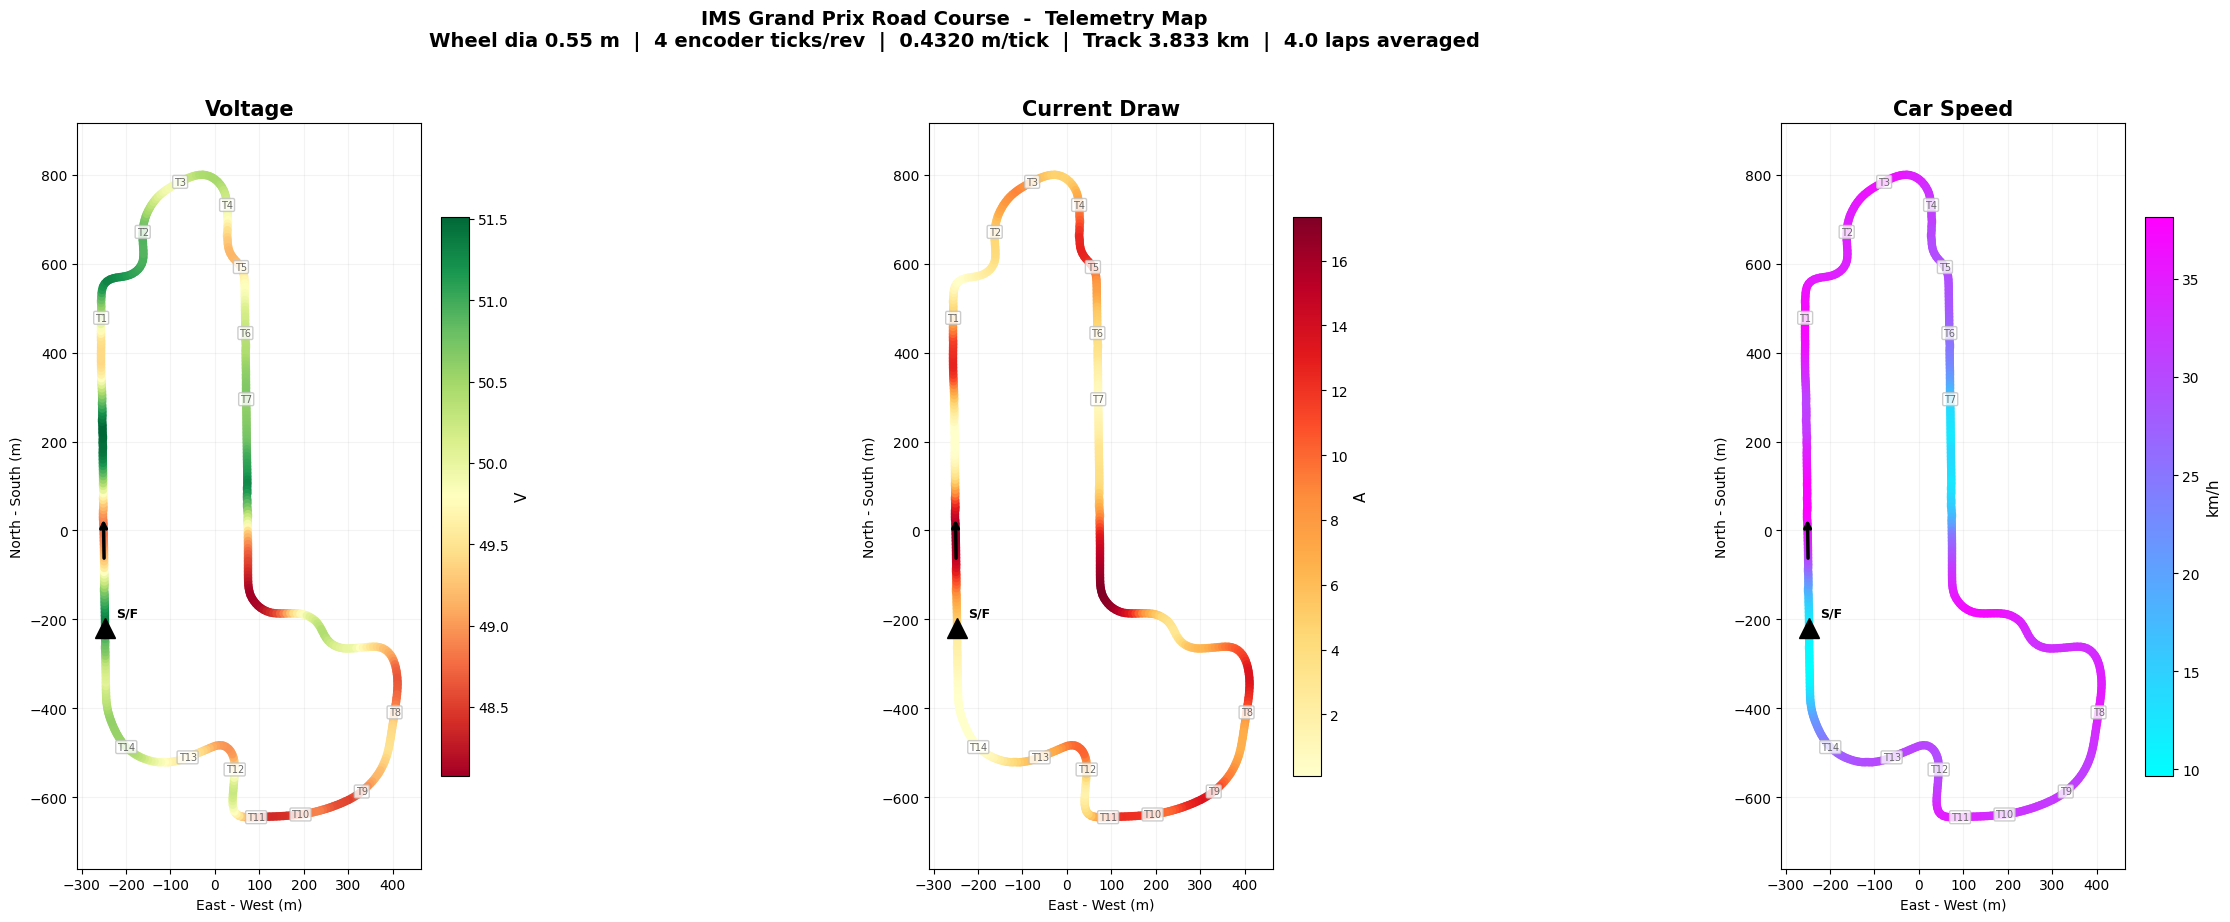

Saved: ims_telemetry_map.png


In [22]:
binned = ea.compute_binned_track_metrics(
    df=df,
    accel=accel,
    track_len_m=TRACK_LEN,
    n_bins=500,
    smooth_window=15,
 )

bin_mids = binned["bin_mids"]
s_bin = binned["s_bin"]
c_bin = binned["c_bin"]
v_bin = binned["v_bin"]
a_bin = binned["a_bin"]
sv_bin = binned["sv_bin"]

ea.plot_three_panel_track_map(
    binned=binned,
    dist_to_xy=dist_to_xy,
    wheel_diam_m=TELEMETRY_CONFIG.wheel_diam_m,
    encoder_ticks_per_rev=TELEMETRY_CONFIG.encoder_ticks_per_rev,
    dist_per_tick_m=summary["dist_per_tick_m"],
    track_len_m=TRACK_LEN,
    n_laps=summary["n_laps"],
    output_path="ims_telemetry_map.png",
 )

# Interactive Track Map — Per-Tick Slider
Drag the slider (or press play) to move the car around the real GPS track.  
Use the **Overlay** dropdown to switch the coloured metric behind the car.

In [23]:
print("Interactive map setup is now handled in the next cell.")

Interactive map setup is now handled in the next cell.


In [24]:
build_interactive_track_map(
    df=df,
    track_len_m=TRACK_LEN,
    bin_mids=bin_mids,
    s_bin=s_bin,
    c_bin=c_bin,
    v_bin=v_bin,
    a_bin=a_bin,
    sv_bin=sv_bin,
    gps_track_csv=str(track_csv_path),
    enable_widgets=True,  # enables play/slider controls
 )

GPS track: 3833 pts, 3833 m
Mapped 38657 telemetry samples to GPS coords


    'data': [{'hoverinfo': 'skip',
              'lat': {'bdata': ('mdTQBmDlQ0Dg…

ValueError: 
Invalid property path 'map._derived' for layout
